### DATASET SELECTION

The dataset used is a telecom customer churn dataset.
This dataset is considered realistic and challenging (“messy”) because:

It contains missing values in several numerical features (e.g., MonthlyRevenue, MonthlyMinutes), requiring proper imputation
Some columns initially have inconsistent or incorrect data types (e.g., categorical values stored as objects), which need preprocessing
It includes a mix of numerical and categorical variables, requiring encoding techniques such as one-hot encoding
There is a clear class imbalance in the target variable (Churn), where non-churn customers dominate, making model evaluation more complex

Additionally, the dataset contains behavioral, demographic, and service-related features, allowing for meaningful feature engineering and pattern discovery.

This makes it highly suitable for demonstrating:

Data cleaning and preprocessing
Feature engineering
Handling imbalanced data
Applying and comparing **machine learning** models

### PROBLEM STATEMENT

The goal of this project is to predict whether a customer will **churn (leave the telecom service)** or not.

Customer churn is a critical problem for telecom companies because:
- Acquiring new customers is more expensive than retaining existing ones
- Identifying potential churners helps companies take preventive actions

This is a **binary classification problem**, where:
- 1 → Customer churns
- 0 → Customer stays

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### LOADING THE DATA

In [110]:
df = pd.read_csv("cell2celltrain.csv")

df.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


###  Feature Grouping & Explanation

To better understand the dataset, features were grouped based on their meaning and role in customer behavior analysis.

---

#### 🔹 1. Customer Identification

- **CustomerID** → Unique identifier for each customer  

👉 This column is used only for **identification** and is **not useful for prediction**, so it is removed during modeling.

---

#### 🔹 2. Target Variable

- **Churn** → Indicates whether the customer left the service (**Yes/No**)  

👉 This is the **dependent variable** that the model aims to predict.

---

#### 🔹 3. Revenue & Billing Features

- **MonthlyRevenue**  
- **TotalRecurringCharge**  
- **OverageMinutes**  
- **RoamingCalls**  

👉 These features represent **customer spending behavior**.

✔ **Insight:**
- **High or unstable charges** may increase churn probability  

---

#### 🔹 4. Usage & Activity Features

- **MonthlyMinutes**  
- **InboundCalls**, **OutboundCalls**, **ReceivedCalls**  
- **PeakCallsInOut**, **OffPeakCallsInOut**  
- **ThreewayCalls**  

👉 These describe **how actively a customer uses the service**.

✔ **Insight:**
- **Low usage** may indicate disengagement  
- **High usage** may indicate dependency  

---

#### 🔹 5. Call Quality & Service Issues

- **DroppedCalls**  
- **BlockedCalls**  
- **UnansweredCalls**  
- **DroppedBlockedCalls**  

👉 These measure **network/service quality**.

✔ **Insight:**
- **Poor call quality** → higher dissatisfaction → higher churn  

---

#### 🔹 6. Customer Support & Complaints

- **CustomerCareCalls**  
- **CallForwardingCalls**  
- **CallWaitingCalls**  

👉 These indicate **customer interaction with support services**.

✔ **Insight:**
- **Frequent complaints** often correlate with churn  

---

#### 🔹 7. Customer Lifecycle / Tenure

- **MonthsInService**  
- **CurrentEquipmentDays**  

👉 These represent **customer loyalty and duration**.

✔ **Insight:**
- **New customers** are more likely to churn  
- **Long-term customers** are more stable  

---

#### 🔹 8. Subscription & Plan Details

- **ActiveSubs**  
- **UniqueSubs**  
- **Handsets**  
- **HandsetModels**  

👉 These describe **customer’s plan and device usage**.

✔ **Insight:**
- **More subscriptions** may indicate higher engagement  

---

#### 🔹 9. Demographic Features

- **AgeHH1**, **AgeHH2**  
- **IncomeGroup**  
- **MaritalStatus**  
- **Occupation**  
- **ChildrenInHH**  

👉 These represent **customer background**.

✔ **Insight:**
- Different **demographic groups** show different churn behavior  

---

#### 🔹 10. Lifestyle & Ownership Features

- **Homeownership**  
- **OwnsComputer**  
- **HasCreditCard**  
- **TruckOwner**, **RVOwner**, **OwnsMotorcycle**  

👉 These indicate **financial and lifestyle status**.

✔ **Insight:**
- **Financial stability** may influence churn  

---

#### 🔹 11. Marketing & Engagement

- **BuysViaMailOrder**  
- **RespondsToMailOffers**  
- **OptOutMailings**  
- **ReferralsMadeBySubscriber**  

👉 These show **customer engagement with marketing efforts**.

✔ **Insight:**
- **Engaged customers** are less likely to churn  

---

#### 🔹 12. Retention & Company Interaction

- **RetentionCalls**  
- **RetentionOffersAccepted**  
- **MadeCallToRetentionTeam**  

👉 These indicate **company efforts to retain customers**.

✔ **Insight:**
- Customers contacted for retention may have **higher churn risk**  
- **Successful offers** can reduce churn  

---

#### 🔹 13. Geographic Features

- **ServiceArea**  
- **PrizmCode**  

👉 These represent **location and regional classification**.

✔ **Insight:**
- Churn may vary across **different regions**  

---

#### 🔹 14. Device & Technology Features

- **HandsetPrice**  
- **HandsetRefurbished**  
- **HandsetWebCapable**  

👉 These describe **device capability and quality**.

✔ **Insight:**
- **Better devices** may improve customer experience and reduce churn  

---

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

### DATA CLEANING

In [112]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

##### What it does?
- Converts all columns in num_cols to numeric (int/float) type
- Any invalid or non-numeric values are replaced with NaN


##### Why it is needed
- Some columns may contain incorrect data types (e.g., numbers stored as strings)
- Machine learning models require pure numeric input
- Ensures data consistency before scaling, modeling, or calculations

In [113]:
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')


In [114]:
df[num_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   MonthlyRevenue             50891 non-null  float64
 2   MonthlyMinutes             50891 non-null  float64
 3   TotalRecurringCharge       50891 non-null  float64
 4   DirectorAssistedCalls      50891 non-null  float64
 5   OverageMinutes             50891 non-null  float64
 6   RoamingCalls               50891 non-null  float64
 7   PercChangeMinutes          50680 non-null  float64
 8   PercChangeRevenues         50680 non-null  float64
 9   DroppedCalls               51047 non-null  float64
 10  BlockedCalls               51047 non-null  float64
 11  UnansweredCalls            51047 non-null  float64
 12  CustomerCareCalls          51047 non-null  float64
 13  ThreewayCalls              51047 non-null  flo

In [115]:
df[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Churn                    51047 non-null  object
 1   ServiceArea              51023 non-null  object
 2   ChildrenInHH             51047 non-null  object
 3   HandsetRefurbished       51047 non-null  object
 4   HandsetWebCapable        51047 non-null  object
 5   TruckOwner               51047 non-null  object
 6   RVOwner                  51047 non-null  object
 7   Homeownership            51047 non-null  object
 8   BuysViaMailOrder         51047 non-null  object
 9   RespondsToMailOffers     51047 non-null  object
 10  OptOutMailings           51047 non-null  object
 11  NonUSTravel              51047 non-null  object
 12  OwnsComputer             51047 non-null  object
 13  HasCreditCard            51047 non-null  object
 14  NewCellphoneUser         51047 non-nul

#### 🔹 Cleaning Categorical Text Data

In [116]:
df[cat_cols] = df[cat_cols].apply(lambda x: x.str.strip().str.title())


In [117]:
df[df["HandsetPrice"]=="Unknown"]

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
28,3000174,Yes,16.14,4.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,6,No,0,Unknown,No,1-Highest,Suburban,Professional,Yes
36,3000230,No,20.18,1.0,20.0,0.00,0.0,0.0,0.0,-0.2,...,0,7,No,0,Unknown,No,1-Highest,Town,Other,No
38,3000238,No,37.99,71.0,38.0,0.00,0.0,0.0,146.0,0.0,...,0,7,No,0,Unknown,No,1-Highest,Other,Other,Yes
43,3000290,No,17.43,20.0,17.0,0.00,1.0,0.0,15.0,1.3,...,0,4,No,0,Unknown,No,4-Medium,Town,Other,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51033,3399882,Yes,38.34,320.0,30.0,0.99,21.0,0.0,-66.0,-8.3,...,0,6,No,0,Unknown,No,1-Highest,Other,Professional,No
51035,3399894,No,0.00,76.0,30.0,0.00,0.0,0.0,0.0,0.0,...,0,4,No,0,Unknown,No,2-High,Other,Professional,No
51037,3399906,No,31.92,63.0,17.0,0.00,43.0,0.0,-38.0,-13.2,...,0,3,No,0,Unknown,No,3-Good,Other,Other,Yes
51039,3399922,No,50.00,492.0,50.0,0.00,0.0,0.0,0.0,0.0,...,0,0,No,0,Unknown,No,6-Verylow,Suburban,Other,Unknown


In [118]:
df["HandsetPrice"] = df["HandsetPrice"].apply(pd.to_numeric, errors='coerce')

In [119]:
df["HandsetPrice"].isna().sum()

np.int64(28982)

In [120]:
df["HandsetPrice"].info()


<class 'pandas.core.series.Series'>
RangeIndex: 51047 entries, 0 to 51046
Series name: HandsetPrice
Non-Null Count  Dtype  
--------------  -----  
22065 non-null  float64
dtypes: float64(1)
memory usage: 398.9 KB


### Missing Value Handling (HandsetPrice)

- Fills missing values in HandsetPrice using the median value within each IncomeGroup
- Instead of using a global value, it performs group-wise imputation


##### Why we did NOT drop the column
- The column has **~28,982 missing** values, but still contains valuable information
- Dropping it would:
- Remove an important feature 
- Reduce model performance 
- Dropping rows would result in massive data loss **(~50%)**

##### Why group-wise imputation (IncomeGroup)
- HandsetPrice is related to IncomeGroup
- Higher income → expensive devices
- Lower income → cheaper devices

##### So instead of:

- Global median **(loses context)**

##### We use:

- Group median **(context-aware imputation)**

##### Why MEDIAN (not mean)
- Data is skewed (right-skewed with outliers)
- Mean gets affected by extreme values 
- Median is robust to outliers 

**KNN IMPUTATION**-Avoid on massive datasets, as calculating the distance between all points is computationally expensive and slow. 

In [121]:
df['HandsetPrice'] = df.groupby('IncomeGroup')['HandsetPrice'].transform(
    lambda x: x.fillna(x.median())
)

In [122]:
print(df["CreditRating"].unique())

['1-Highest' '4-Medium' '3-Good' '6-Verylow' '2-High' '5-Low' '7-Lowest']


In [123]:

df['CreditRating'] = df['CreditRating'].str.extract('(\d+)').astype(int)
df['CreditRating'] = df['CreditRating'].max() + 1 - df['CreditRating']

In [124]:
print(df["CreditRating"].unique())

[7 4 5 2 6 3 1]


In [125]:
df[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Churn                    51047 non-null  object 
 1   ServiceArea              51023 non-null  object 
 2   ChildrenInHH             51047 non-null  object 
 3   HandsetRefurbished       51047 non-null  object 
 4   HandsetWebCapable        51047 non-null  object 
 5   TruckOwner               51047 non-null  object 
 6   RVOwner                  51047 non-null  object 
 7   Homeownership            51047 non-null  object 
 8   BuysViaMailOrder         51047 non-null  object 
 9   RespondsToMailOffers     51047 non-null  object 
 10  OptOutMailings           51047 non-null  object 
 11  NonUSTravel              51047 non-null  object 
 12  OwnsComputer             51047 non-null  object 
 13  HasCreditCard            51047 non-null  object 
 14  NewCellphoneUser      

In [126]:
df.isna().sum()

CustomerID                     0
Churn                          0
MonthlyRevenue               156
MonthlyMinutes               156
TotalRecurringCharge         156
DirectorAssistedCalls        156
OverageMinutes               156
RoamingCalls                 156
PercChangeMinutes            367
PercChangeRevenues           367
DroppedCalls                   0
BlockedCalls                   0
UnansweredCalls                0
CustomerCareCalls              0
ThreewayCalls                  0
ReceivedCalls                  0
OutboundCalls                  0
InboundCalls                   0
PeakCallsInOut                 0
OffPeakCallsInOut              0
DroppedBlockedCalls            0
CallForwardingCalls            0
CallWaitingCalls               0
MonthsInService                0
UniqueSubs                     0
ActiveSubs                     0
ServiceArea                   24
Handsets                       1
HandsetModels                  1
CurrentEquipmentDays           1
AgeHH1    

In [127]:
(df.isnull().any(axis=1).sum() / len(df)) * 100


np.float64(2.5368777793014283)

- Only ~2.5% of total data had missing values
- This is a very small portion, so dropping does not significantly affect the dataset

In [128]:
cols_to_drop = [col for col in df.columns if df[col].nunique() <= 1] 
cols_to_drop

[]

In [129]:
df = df.dropna()

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49752 entries, 0 to 51043
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 49752 non-null  int64  
 1   Churn                      49752 non-null  object 
 2   MonthlyRevenue             49752 non-null  float64
 3   MonthlyMinutes             49752 non-null  float64
 4   TotalRecurringCharge       49752 non-null  float64
 5   DirectorAssistedCalls      49752 non-null  float64
 6   OverageMinutes             49752 non-null  float64
 7   RoamingCalls               49752 non-null  float64
 8   PercChangeMinutes          49752 non-null  float64
 9   PercChangeRevenues         49752 non-null  float64
 10  DroppedCalls               49752 non-null  float64
 11  BlockedCalls               49752 non-null  float64
 12  UnansweredCalls            49752 non-null  float64
 13  CustomerCareCalls          49752 non-null  float64


### Encoding Binary Categorical Variables

In [131]:
binary_cols = [
    'ChildrenInHH','HandsetRefurbished','HandsetWebCapable',
    'TruckOwner','RVOwner','BuysViaMailOrder','RespondsToMailOffers',
    'OptOutMailings','NonUSTravel','OwnsComputer','HasCreditCard',
    'NewCellphoneUser','NotNewCellphoneUser','OwnsMotorcycle',
    'MadeCallToRetentionTeam','Churn'
]

df[binary_cols] = df[binary_cols].replace({'Yes':1, 'No':0})

C:\Users\lenovo\AppData\Local\Temp\ipykernel_27616\1338416990.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'Yes':1, 'No':0})


##### Dropping Unnecessary Columns

In [132]:
df.drop(columns=['NotNewCellphoneUser','CustomerID'], inplace=True)

In [133]:
df['Homeownership'] = df['Homeownership'].map({'Known':1, 'Unknown':0})

In [134]:
df.duplicated().sum()

np.int64(0)

In [135]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

### EDA (Exploratory Data Analysis)

#### Target Variable Analysis (Churn Distribution)

- The dataset is imbalanced

##### Problem due to imbalance
- Model may become biased toward majority class (Non-churn)
- High accuracy but very low recall for churn class


Churn
0    0.71368
1    0.28632
Name: proportion, dtype: float64


<Axes: xlabel='Churn', ylabel='count'>

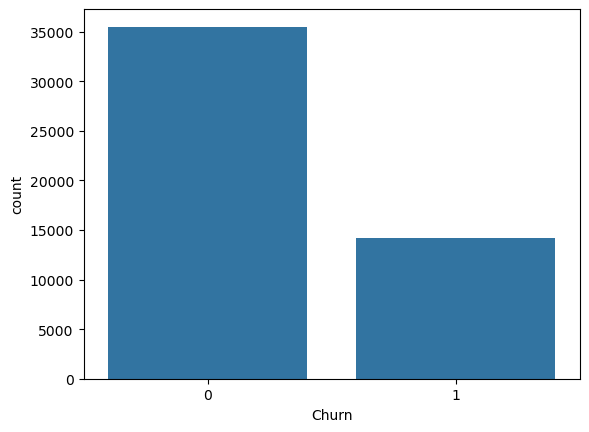

In [136]:
print(df['Churn'].value_counts(normalize=True))
sns.countplot(x='Churn', data=df)

### Distribution Analysis of Some Numerical Features

- Helps visualize data distribution, skewness, and spread

#### Observation
- Most features show right-skewed distribution
- Majority of values are concentrated at lower ranges
- Few extreme values extend to very high values → outliers present

#### Why this step is important
- Identifies skewness in data
- Detects presence of outliers

#### WHEN SKEW IS A PROBLEM
- Linear models (like Logistic Regression)
    - coefficients get biased
    - model struggles with extreme values

#### Distance-based models (KNN, SVM)
- large values dominate distance
- model becomes unstable


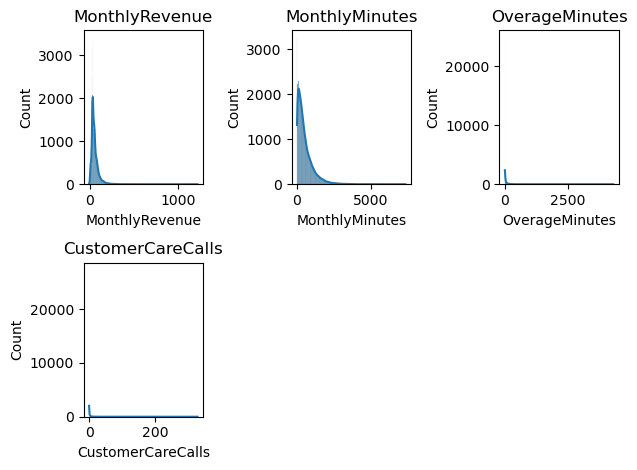

In [137]:
num_cols = ['MonthlyRevenue', 'MonthlyMinutes', 'OverageMinutes', 'CustomerCareCalls']

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

<Axes: xlabel='MonthlyRevenue', ylabel='Density'>

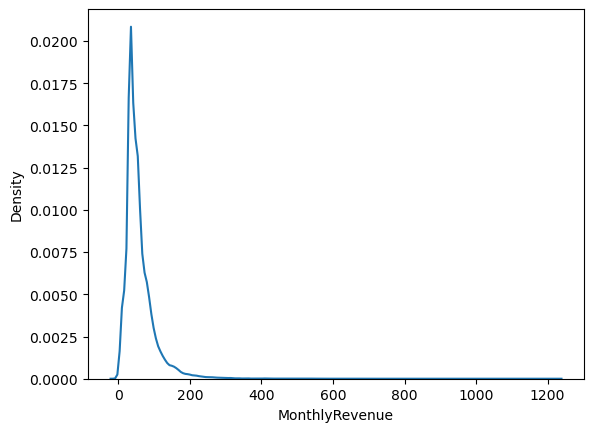

In [138]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.kdeplot(df['MonthlyRevenue'])

#### Outlier Detection using Boxplots

Outliers can:
- Distort model learning
- Affect distance-based algorithms (KNN, SVM)
- Bias mean-based calculations

Observation
- Many features contain significant outliers

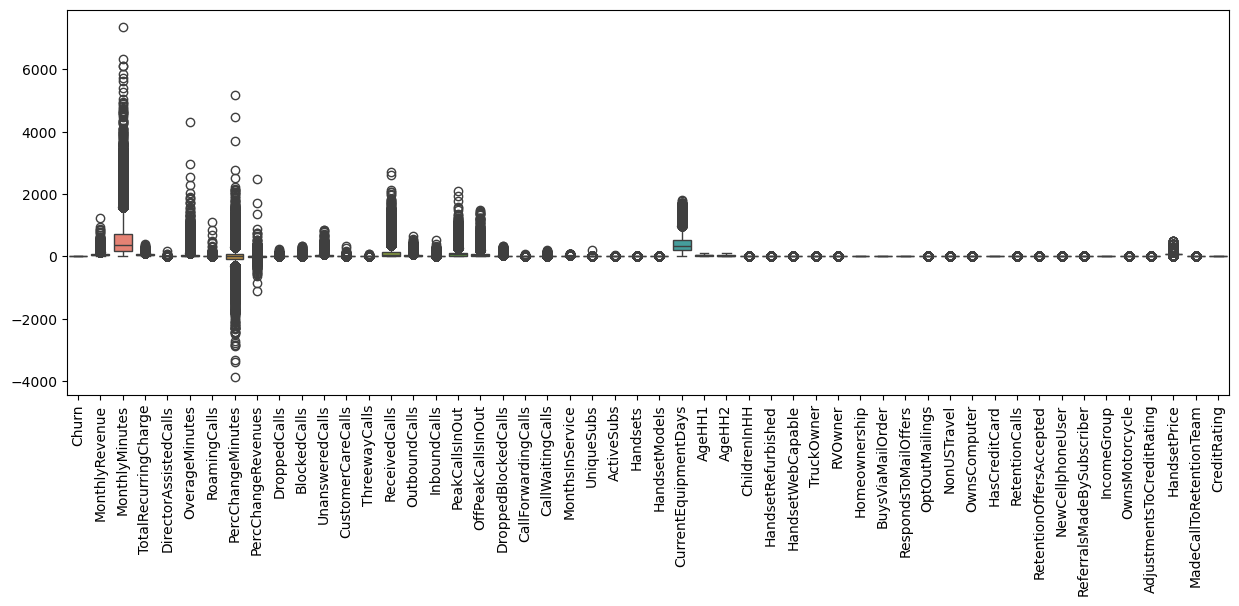

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.show()


##### Outlier Detection using IQR Method (Custom Function)

Why IQR method is used
- Works well for skewed data
- Does not assume normal distribution
- More robust than mean-based methods (like Z-score)

Why not Z-score method
- Z-score assumes normal distribution
- Our data is right-skewed (as seen in EDA)

In [140]:
def detect_outliers(df, cols):
    outlier_cols = []

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # check if any value outside bounds
        if ((df[col] < lower) | (df[col] > upper)).any():
            outlier_cols.append(col)

    return outlier_cols

In [141]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
# remove binary / low-unique columns
num_cols = [col for col in num_cols if df[col].nunique() > 20]
outlier_cols = detect_outliers(df, num_cols)


print("Columns with outliers:")
print(outlier_cols)

Columns with outliers:
['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'Handsets', 'CurrentEquipmentDays']


#### Outlier Treatment using IQR Capping

What it does
- Applies IQR-based outlier capping on selected columns
- Values outside the range:[Q1 - 1.5 × IQR , Q3 + 1.5 × IQR] are clipped to the boundary values

Why CAPPING (not removing)
- Outliers may represent real customer behavior
- e.g., heavy usage customers

Removing them would:

- Lose important information 

So we:

- Limit extreme values instead 




c:\Users\lenovo\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\lenovo\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


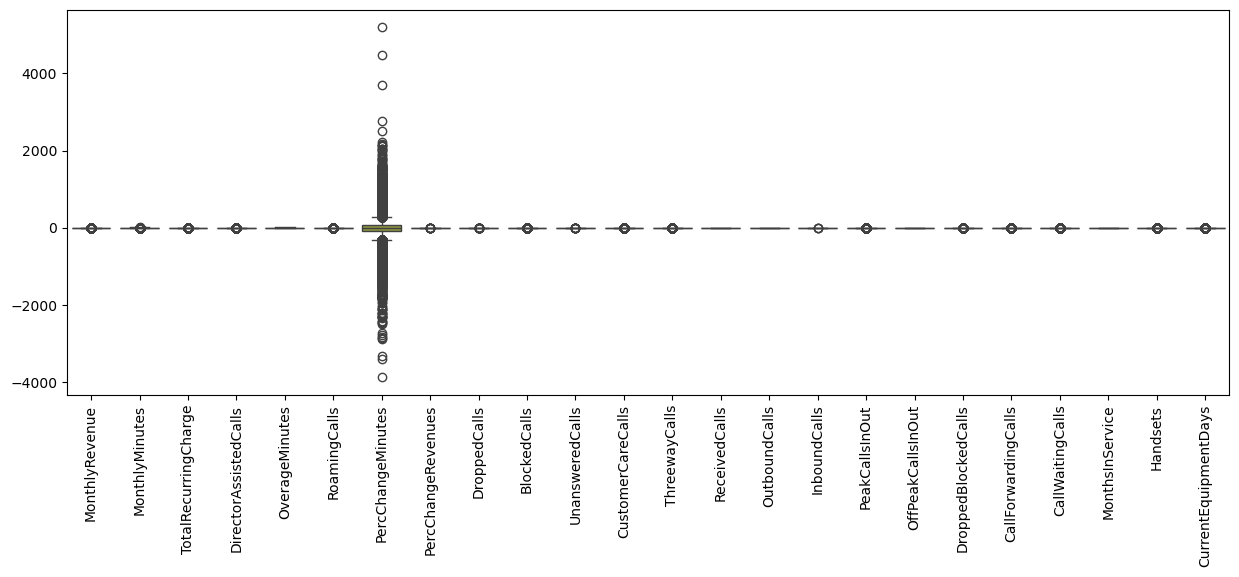

In [142]:
import numpy as np

skewed_cols = df[num_cols].skew().sort_values(ascending=False)

skewed_cols = skewed_cols[skewed_cols > 1].index  # threshold

for col in skewed_cols:
    df[col] = np.log1p(df[col])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
sns.boxplot(data=df[outlier_cols])
plt.xticks(rotation=90)
plt.show()

Before Capping

- Distribution is **heavily right-skewed**
- Presence of **extreme high values (outliers)**
- Long tail extending to very large values  

After Capping

- Distribution becomes **more concentrated**
- Extreme values are limited to **upper bounds** and **lower bounds**
- Shape becomes more **smooth** and **interpretable**

Impact on Model
- Reduces bias caused by extreme values
- Improves performance of:
    - KNN
    - SVM
    - Logistic Regression


The distribution will still not be normal but yes better than heavily skewed and will be usable causing less bias in model

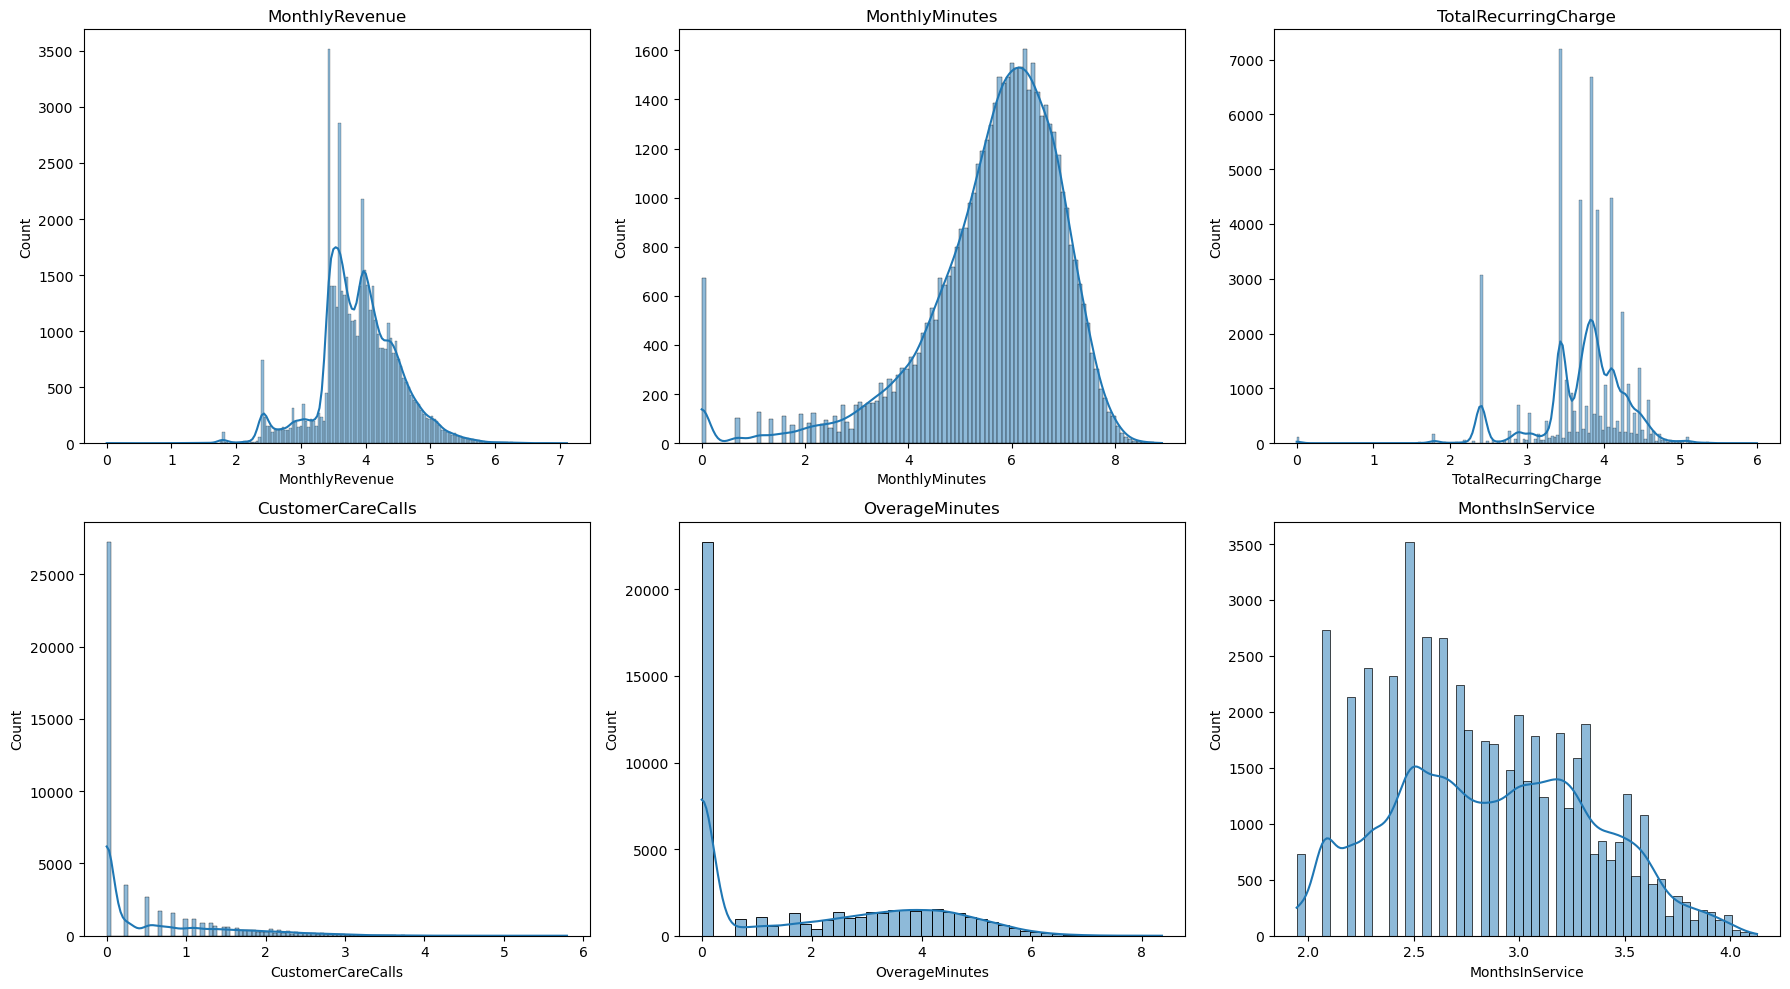

In [143]:
cont_cols = [
    'MonthlyRevenue',
    'MonthlyMinutes',
    'TotalRecurringCharge',
    'CustomerCareCalls',
    'OverageMinutes',
    'MonthsInService',
    
]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 10))

for i, col in enumerate(cont_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

Feature vs Churn Analysis (Boxplots)

**What it does**
- Compares distribution of numerical features across Churn = 0 and Churn = 1
- Helps identify whether a feature differs between churn and non-churn customers

Observations

**1. MonthlyRevenue**
- Distributions for churn and non-churn are very similar
- No strong separation

Insight:

- Revenue alone is not a strong predictor

**2. MonthlyMinutes**
- Slight variation between groups
- Significant overlap

Insight:

Usage alone does not clearly separate churn

**3. TotalRecurringCharge**
- Almost identical distribution for both classes

Insight:

- Fixed charges have weak influence

**4. CustomerCareCalls**
- Churn customers show slightly higher complaints

Insight:

- More complaints → higher churn probability 

**5. OverageMinutes**
- Churn customers tend to have higher overage usage

Insight:

- Extra usage charges may increase dissatisfaction

**6. MonthsInService**
- Churn customers have slightly lower tenure

Insight:

- New customers are more likely to churn 

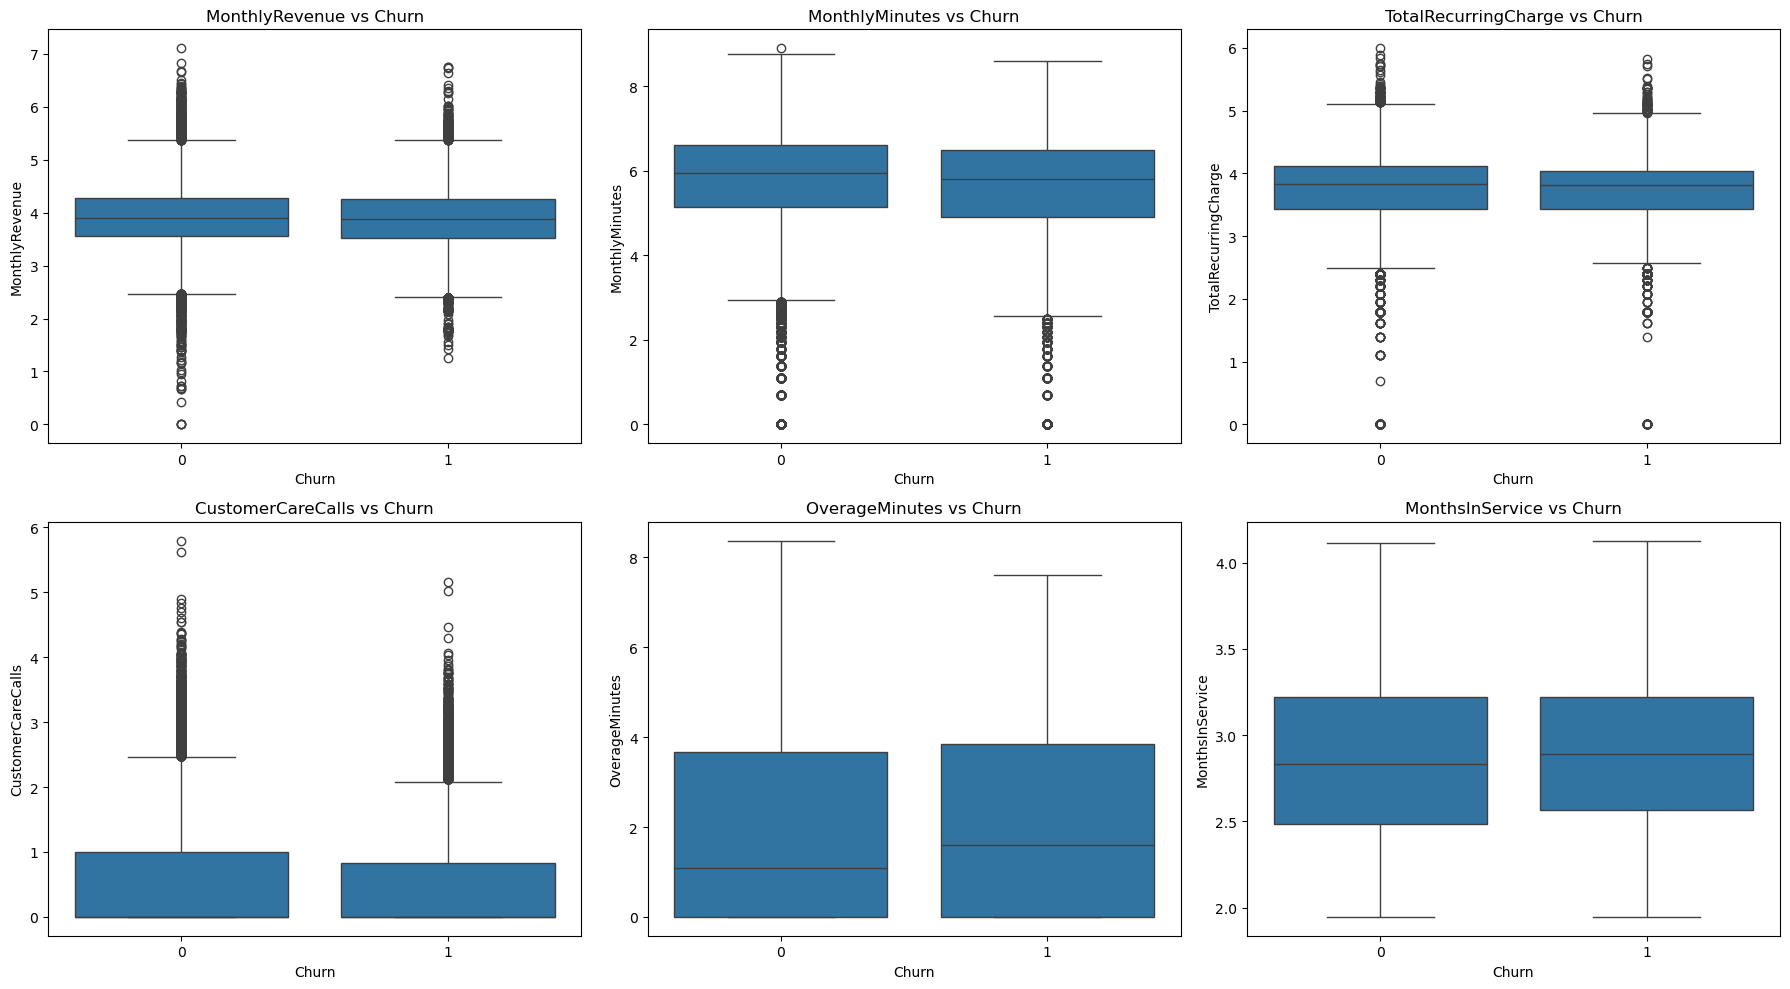

In [144]:
plt.figure(figsize=(18, 10))

for i, col in enumerate(cont_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

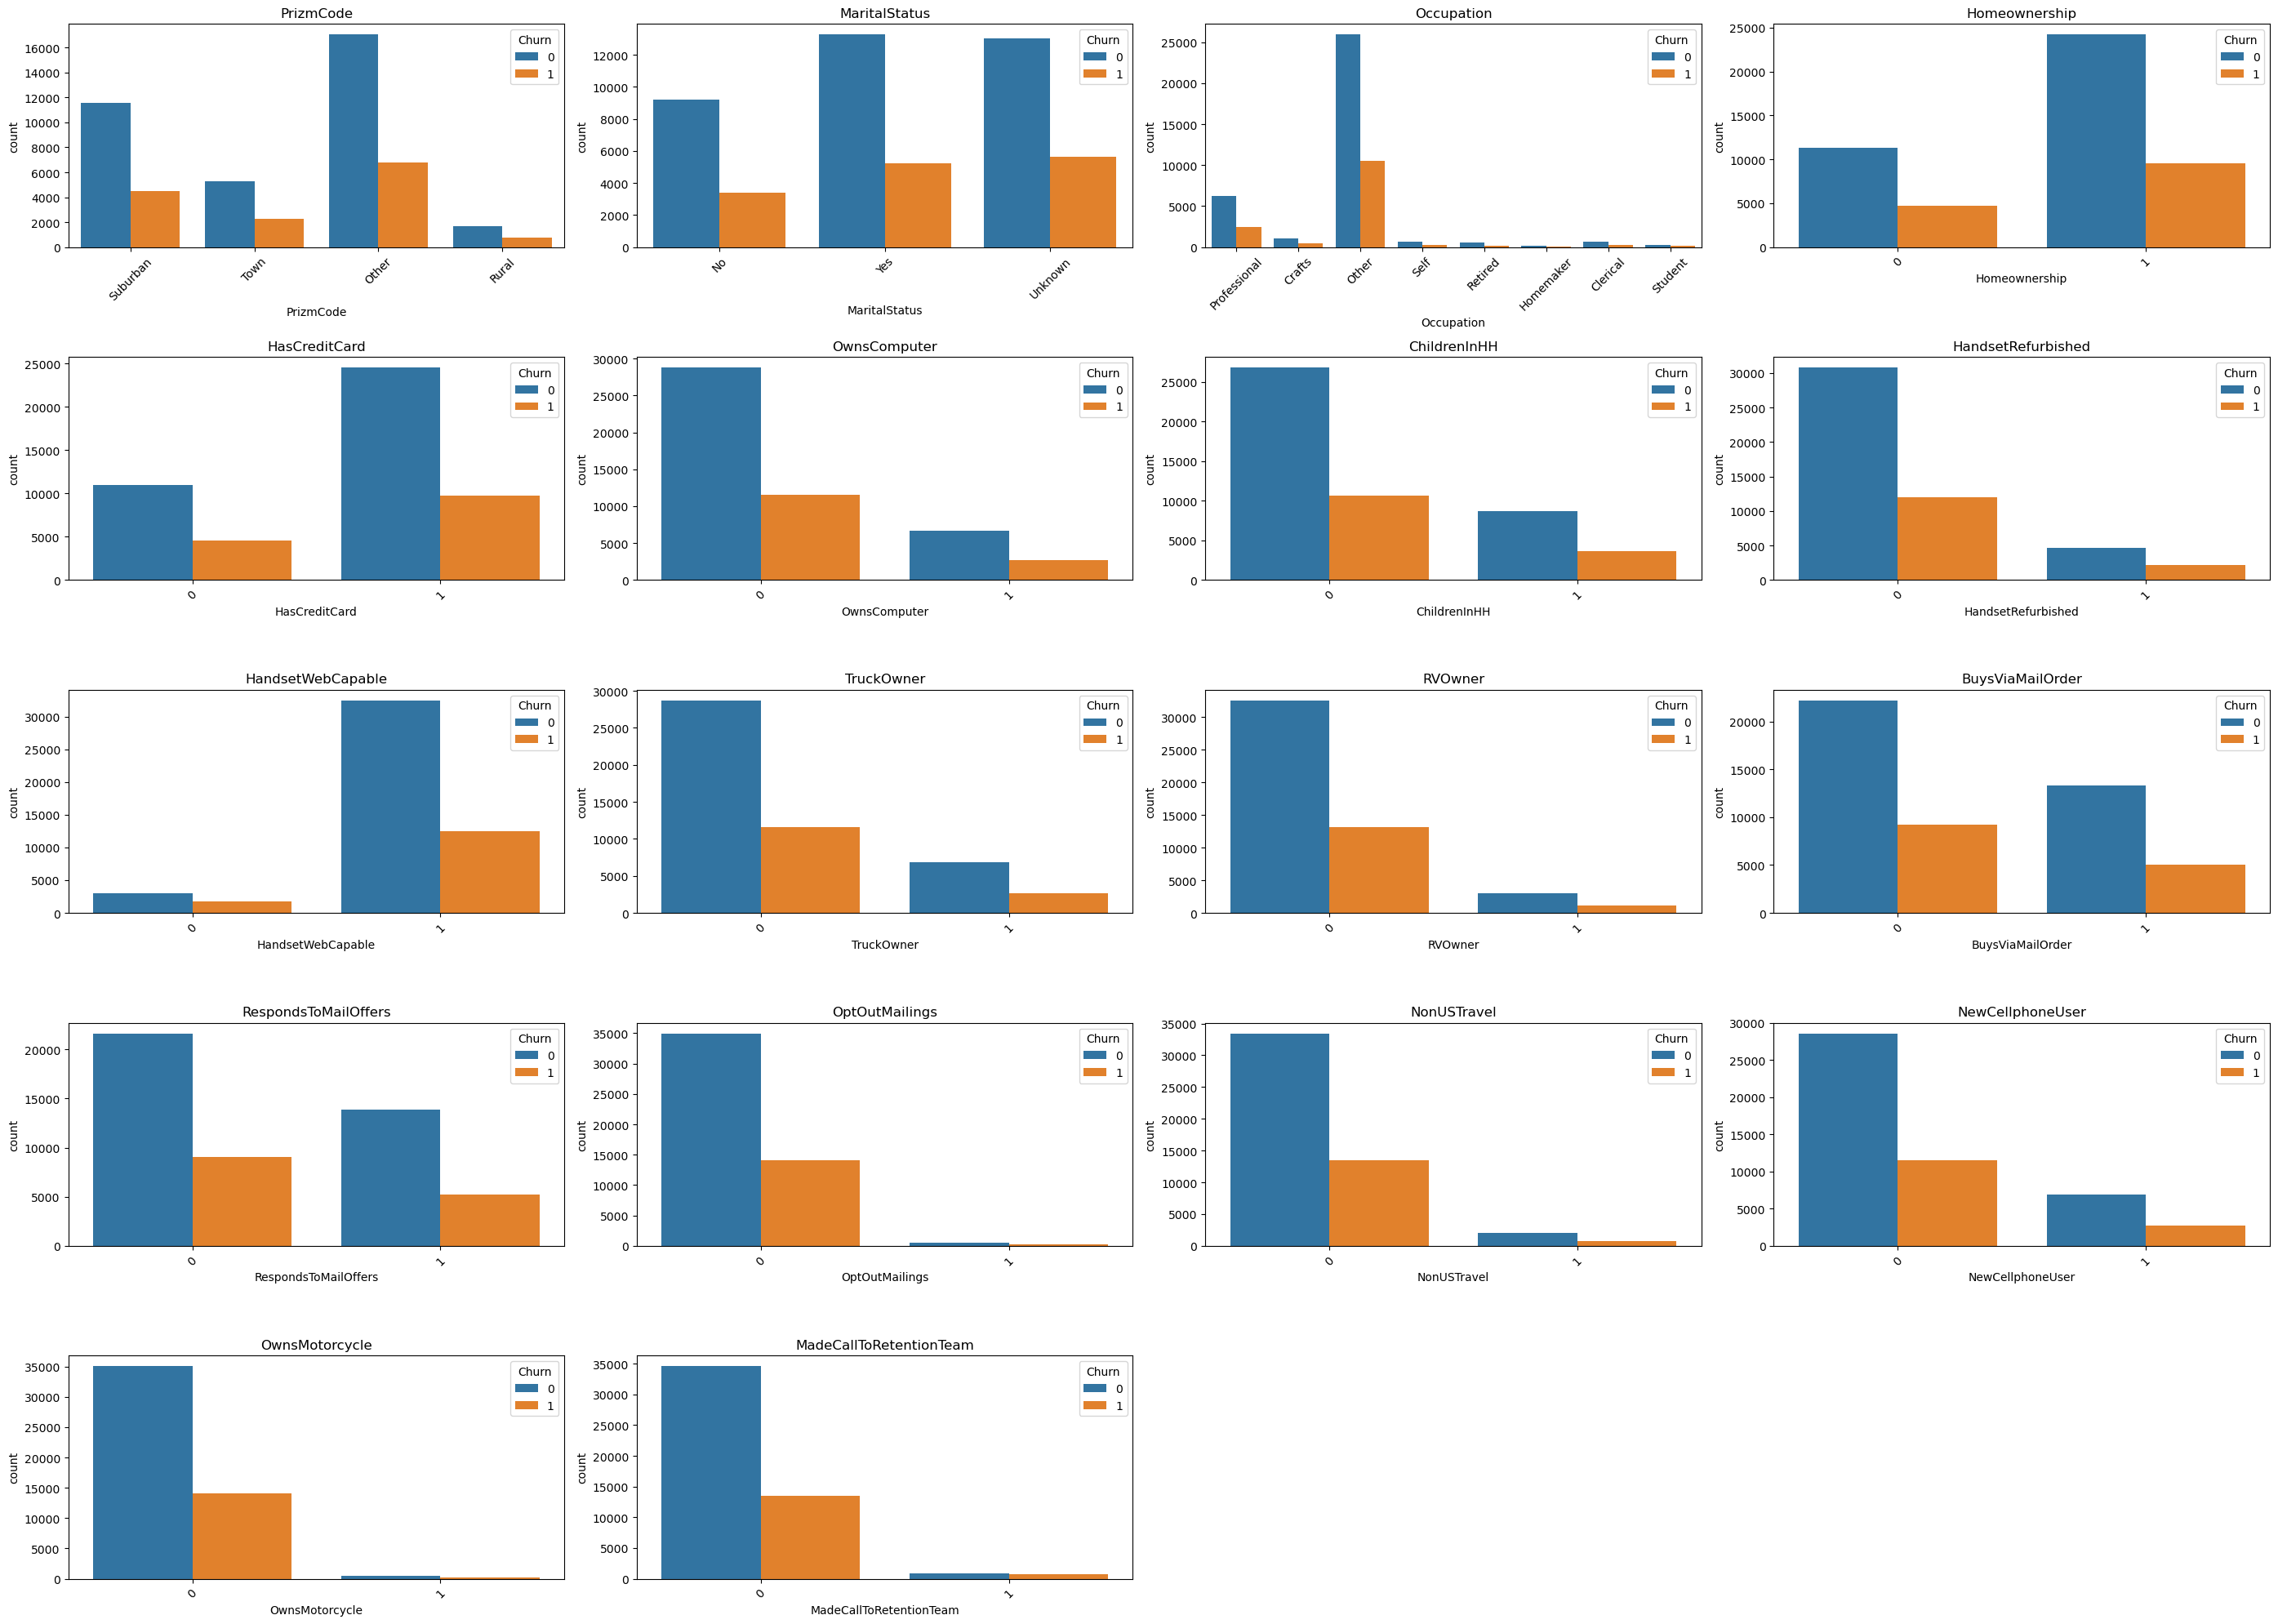

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = [
    'PrizmCode',
    'MaritalStatus',
    'Occupation',
    'Homeownership',
    'HasCreditCard',
    'OwnsComputer',
    'ChildrenInHH',
    'HandsetRefurbished',
    'HandsetWebCapable',
    'TruckOwner',
    'RVOwner',
    'BuysViaMailOrder',
    'RespondsToMailOffers',
    'OptOutMailings',
    'NonUSTravel',
    'NewCellphoneUser',
    'OwnsMotorcycle',
    'MadeCallToRetentionTeam',
]

plt.figure(figsize=(28, 20))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(5, 4, i)
    sns.countplot(x=col, hue="Churn", data=df)
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

#### Feature Engineering 

Feature engineering was performed to create **more meaningful and informative variables** from raw data, as individual features showed **weak correlation and high overlap with churn**.

Why Feature Engineering was needed

- Raw features showed:
  - **Low correlation with churn**
  - **High overlap in distributions**
- No single feature could explain churn behavior  

**Therefore New derived features were created to capture hidden patterns**

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

##### Engineered Features (Detailed Explanation)

**1.TotalCalls**

Why:

- Combines overall communication activity
- Better than using inbound/outbound separately

Insight:

-Total engagement level of customer 

**2.MinutesPerCall**

Why:

- Raw minutes don’t show call behavior
- This shows average call duration

Insight:

- Long calls vs frequent short calls 

**3.CallsPerDay**

Why:

- Normalizes usage over time
- Avoids bias from long-tenure customers

Insight:

- Daily engagement intensity 

**4.UnansweredRate**

Why:

- Absolute values don’t reflect proportion
- Rate shows call inefficiency

Insight:

- Higher unanswered rate → poor experience 

**5.FailureRate**

Why:

- Combines network-related issues
- Better than separate features

Insight:

- Network quality indicator 

**6.CostPerMinute**

Why:

- Revenue alone is misleading
- This shows cost efficiency

Insight:

- Higher cost → dissatisfaction risk 

**7.OverageRatio**

Why:

- Absolute overage doesn’t show proportion
- Ratio shows extra usage burden

Insight:

- Frequent overage → higher bills → churn 

**8.ComplaintRate**

Why:

- Complaints should be relative to usage

Insight:

- More complaints → higher dissatisfaction 

**9.RetentionSuccessRate**

Why:

- Measures effectiveness of retention efforts

Insight:

- Higher success → reduced churn 

**10.RetentionContacted**

Why:

- Converts into binary feature
- Indicates whether customer was targeted

Insight:

- Retention contact → high churn risk group 

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [146]:
df['TotalCalls'] = df['InboundCalls'] + df['OutboundCalls']
df['MinutesPerCall'] = df['MonthlyMinutes'] / (df['TotalCalls'] + 1)
df['CallsPerDay'] = df['TotalCalls'] / (df['MonthsInService'] + 1)
df['UnansweredRate'] = df['UnansweredCalls'] / (df['TotalCalls'] + 1)
df['FailureRate'] = (df['DroppedCalls'] + df['BlockedCalls']) / (df['TotalCalls'] + 1)
df['CostPerMinute'] = df['MonthlyRevenue'] / (df['MonthlyMinutes'] + 1)
df['OverageRatio'] = df['OverageMinutes'] / (df['MonthlyMinutes'] + 1)
df['ComplaintRate'] = df['CustomerCareCalls'] / (df['TotalCalls'] + 1)
df['RetentionSuccessRate'] = df['RetentionOffersAccepted'] / (df['RetentionCalls'] + 1)
df['RetentionContacted'] = (df['RetentionCalls'] > 0).astype(int)
df.groupby('RetentionContacted')['Churn'].mean()   

RetentionContacted
0    0.281295
1    0.435534
Name: Churn, dtype: float64

In [147]:
corr_matrix = df.corr(numeric_only=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49752 entries, 0 to 51043
Data columns (total 66 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      49752 non-null  int64  
 1   MonthlyRevenue             49750 non-null  float64
 2   MonthlyMinutes             49752 non-null  float64
 3   TotalRecurringCharge       49748 non-null  float64
 4   DirectorAssistedCalls      49752 non-null  float64
 5   OverageMinutes             49752 non-null  float64
 6   RoamingCalls               49752 non-null  float64
 7   PercChangeMinutes          49752 non-null  float64
 8   PercChangeRevenues         29110 non-null  float64
 9   DroppedCalls               49752 non-null  float64
 10  BlockedCalls               49752 non-null  float64
 11  UnansweredCalls            49752 non-null  float64
 12  CustomerCareCalls          49752 non-null  float64
 13  ThreewayCalls              49752 non-null  float64


#### Correlation Analysis with Target Variable (Churn)
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

What it does
- Calculates Pearson correlation between all numerical features and Churn
- Sorts features based on their relationship strength

Key Observation
- Most features have very low correlation values
- Highest correlation ≈ 0.10
- Most features between -0.06 to +0.06

This indicates:

- Churn is not dependent on a single feature
- Relationship is complex and non-linear

In [148]:
corr_with_churn = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
print(corr_with_churn)

Churn                      1.000000
CurrentEquipmentDays       0.099327
CostPerMinute              0.090873
MadeCallToRetentionTeam    0.060577
RetentionContacted         0.060577
                             ...   
TotalRecurringCharge      -0.055091
CallsPerDay               -0.056850
OffPeakCallsInOut         -0.058172
HandsetWebCapable         -0.062409
MonthlyMinutes            -0.081231
Name: Churn, Length: 62, dtype: float64


In [149]:
corr_df = corr_with_churn.reset_index()
corr_df.columns = ['Feature', 'Correlation_with_Churn']
print(corr_df)

                    Feature  Correlation_with_Churn
0                     Churn                1.000000
1      CurrentEquipmentDays                0.099327
2             CostPerMinute                0.090873
3   MadeCallToRetentionTeam                0.060577
4        RetentionContacted                0.060577
..                      ...                     ...
57     TotalRecurringCharge               -0.055091
58              CallsPerDay               -0.056850
59        OffPeakCallsInOut               -0.058172
60        HandsetWebCapable               -0.062409
61           MonthlyMinutes               -0.081231

[62 rows x 2 columns]


In [150]:
corr_df[abs(corr_df['Correlation_with_Churn']) > 0.05]

,Feature,Correlation_with_Churn
0,Churn,1.000000
1,CurrentEquipmentDays,0.099327
2,CostPerMinute,0.090873
3,MadeCallToRetentionTeam,0.060577
4,RetentionContacted,0.060577
5,RetentionCalls,0.058422
53,CustomerCareCalls,-0.051063
54,TotalCalls,-0.052232
55,InboundCalls,-0.052335
56,PeakCallsInOut,-0.053946


In [151]:

corr_matrix = df.corr(numeric_only=True).abs()


upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []

for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] > 0.8:
            high_corr_pairs.append((row, col, upper.loc[row, col]))


for pair in high_corr_pairs:
    print(f"{pair[0]}  <--->  {pair[1]}  =  {pair[2]:.2f}")

ReceivedCalls  <--->  OutboundCalls  =  0.84
UnansweredCalls  <--->  PeakCallsInOut  =  0.85
ReceivedCalls  <--->  PeakCallsInOut  =  0.88
OutboundCalls  <--->  PeakCallsInOut  =  0.84
UnansweredCalls  <--->  OffPeakCallsInOut  =  0.86
ReceivedCalls  <--->  OffPeakCallsInOut  =  0.88
OutboundCalls  <--->  OffPeakCallsInOut  =  0.86
PeakCallsInOut  <--->  OffPeakCallsInOut  =  0.89
DroppedCalls  <--->  DroppedBlockedCalls  =  0.87
OffPeakCallsInOut  <--->  DroppedBlockedCalls  =  0.81
Handsets  <--->  HandsetModels  =  0.89
BuysViaMailOrder  <--->  RespondsToMailOffers  =  0.97
RetentionCalls  <--->  MadeCallToRetentionTeam  =  0.96
ReceivedCalls  <--->  TotalCalls  =  0.83
OutboundCalls  <--->  TotalCalls  =  0.95
InboundCalls  <--->  TotalCalls  =  0.94
OffPeakCallsInOut  <--->  TotalCalls  =  0.82
ReceivedCalls  <--->  CallsPerDay  =  0.81
OutboundCalls  <--->  CallsPerDay  =  0.93
InboundCalls  <--->  CallsPerDay  =  0.91
OffPeakCallsInOut  <--->  CallsPerDay  =  0.81
TotalCalls  <-


#### What is Multicollinearity

- Multicollinearity occurs when **two or more features are highly correlated with each other**
- It means they provide **duplicate or redundant information**

Why it is a problem
- 1. Redundant Information
Model gets same signal multiple times
No new information is added
- 2. Unstable Coefficients (Logistic Regression)

Coefficients become:
- unstable and unreliable 

Small data change → big coefficient change

**If two features are highly correlated i.e having correlation>0.8:**
- Keep one
- Drop the other

In [152]:
df.drop(columns=[
    # Calls redundancy
    'TotalCalls',
    'InboundCalls',
    'OutboundCalls',
    'ReceivedCalls',

    # Peak / OffPeak redundancy
    'PeakCallsInOut',
    'OffPeakCallsInOut',

    # Retention redundancy
    'RetentionCalls',
    'MadeCallToRetentionTeam',
    'RetentionOffersAccepted',

    # Marketing redundancy
    'BuysViaMailOrder',

    # Usage redundancy
    'OverageMinutes',
    'CallForwardingCalls','ServiceArea'
], inplace=True)


#### Variance Inflation Factor (VIF)

- VIF measures how much a feature is **explained by other features**
- It detects **multicollinearity**

Interpretation of VIF

| VIF Value | Meaning |
|----------|--------|
| 1        | No correlation |
| 1 – 5    | Moderate correlation |
| 5 – 10   | High correlation |
| > 10     | Very high multicollinearity  |

**NOT drop all features with VIF > 10**
Wrong Approach



##### Problem:

You would remove too many important features
Leads to:
Loss of useful information
**Correct Approach**
- 🔹 Step 1: Identify correlated groups

Example:

MonthlyRevenue ↔ TotalRecurringCharge ↔ MonthlyMinutes
OutboundCalls ↔ TotalCalls ↔ CallsPerDay
RetentionCalls ↔ RetentionContacted ↔ MadeCallToRetentionTeam

- 🔹 Step 2: Keep ONE representative feature

Selection based on:

- Business meaning
- Interpretability
- Engineered feature preference

- 🔹 Step 3: Drop others in group

this approach is better
- 🔸 1. Preserves Information
- 🔸 2. Removes Redundancy
- 🔸 3. Improves Model Stability



In [153]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


X = df.drop('Churn', axis=1)


X = X.select_dtypes(include=['int64', 'float64'])


X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())


X = X.loc[:, X.nunique() > 1]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]


vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

                      Feature         VIF
0              MonthlyRevenue  268.239658
1              MonthlyMinutes  172.190035
2        TotalRecurringCharge  170.723981
12        DroppedBlockedCalls  134.730757
14            MonthsInService   80.860277
19       CurrentEquipmentDays   59.470717
7                DroppedCalls   47.346645
17                   Handsets   46.214085
9             UnansweredCalls   45.315659
41                CallsPerDay   23.478634
18              HandsetModels   19.829511
8                BlockedCalls   17.883051
42             UnansweredRate   15.547523
39               CreditRating   14.975711
43                FailureRate   14.670916
16                 ActiveSubs   13.776719
40             MinutesPerCall   12.555999
44              CostPerMinute   12.548264
24          HandsetWebCapable   11.032605
27              Homeownership   10.618138
32              HasCreditCard   10.216970
20                     AgeHH1    8.889814
35                IncomeGroup    7

In [157]:
# df.drop(columns=[

#     # Revenue / usage cluster (high VIF)
#     'MonthlyRevenue',
#     'TotalRecurringCharge',

#     # Calls cluster (already redundant)
   
   
#     'UnansweredCalls',
#     'DroppedCalls',
#     'DroppedBlockedCalls',

#     # Time/usage redundancy
#     'MonthlyMinutes',   # keep CallsPerDay instead
#     'CallsPerDay',      # OR keep this and drop MonthlyMinutes (choose ONE)

#     # Device cluster
#     'Handsets',

#     # Age redundancy
#     'AgeHH2',

#     # Weak / redundant binary
#     'HasCreditCard'

# ], inplace=True)

df.drop(columns=[

   'UniqueSubs'

], inplace=True)

In [158]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


X = df.drop('Churn', axis=1)


X = X.select_dtypes(include=['int64', 'float64'])


X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())


X = X.loc[:, X.nunique() > 1]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]


vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

                      Feature        VIF
8             MonthsInService  62.708008
11       CurrentEquipmentDays  48.556896
29               CreditRating  14.714357
15          HandsetWebCapable   9.432128
10              HandsetModels   8.400770
18              Homeownership   8.109157
12                     AgeHH1   7.115070
32                FailureRate   7.090263
25                IncomeGroup   6.995325
31             UnansweredRate   6.138960
5           CustomerCareCalls   5.716336
9                  ActiveSubs   5.447992
33              CostPerMinute   5.407373
35              ComplaintRate   4.644666
4                BlockedCalls   4.374827
28               HandsetPrice   4.368542
30             MinutesPerCall   3.158047
34               OverageRatio   2.861712
7            CallWaitingCalls   2.704916
19       RespondsToMailOffers   2.604534
3          PercChangeRevenues   2.334625
16                 TruckOwner   2.241267
37         RetentionContacted   2.142539
36       Retenti

#### 🔹 Train-Test Split 

##### What it does

Separates:
- X → Input features
- y → Target variable (Churn)

In [159]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [160]:
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(exclude='object').columns

#### 🔹 ColumnTransformer (Preprocessing Pipeline)

**What it does?**

Applies different transformations:
- Categorical → OneHotEncoding
- Numerical → kept as it is

**drop='first'**

Prevents dummy variable trap

-  Removes one category to avoid multicollinearity

In [161]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [162]:
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

In [165]:
import numpy as np

X_train_enc = np.where(np.isinf(X_train_enc), np.nan, X_train_enc)
X_test_enc  = np.where(np.isinf(X_test_enc), np.nan, X_test_enc)

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_enc = imputer.fit_transform(X_train_enc)
X_test_enc  = imputer.transform(X_test_enc)

#### 🔹 Feature Scaling using RobustScaler

**What it does?**

Scales numerical features using:
- Median and Interquartile Range (IQR)

**Why scaling is needed?**

Models like:
- Logistic Regression
- KNN
- SVM

needs scaling otherwise bias

**Why NOT StandardScaler?**

Data contains:
- Outliers + Skewness

StandardScaler uses:

- Mean → affected by outliers 
- Std → distorted 

In [166]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

#### 🔹 Feature Selection using RFE (WRAPPER METHOD)

**What it does?**

- Recursively removes least important features
- Keeps only the most relevant ones

**How RFE works?**

- Train model
- Rank features by importance
- Remove weakest feature
- Repeat

**Impact**
- Reduces dimensionality
- Improves model performance
- Prevents overfitting


In [167]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

model = LogisticRegression(max_iter=1000)

rfe = RFE(model)

X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)

In [168]:
model.fit(X_train_rfe, y_train)

y_pred = model.predict(X_test_rfe)

In [169]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.7052557531906342
Recall: 0.01816935207404868
Precision: 0.4344262295081967
F1: 0.03487989470220467


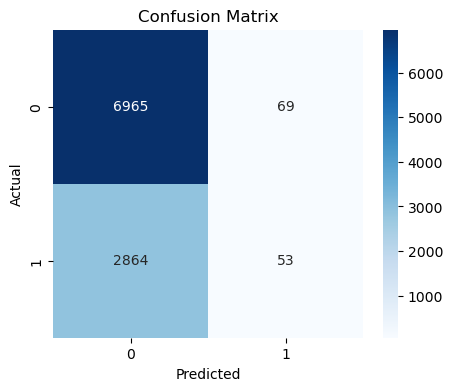

In [170]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#### 🔹 Handling Class Imbalance (Sampling Techniques)

Why Sampling was needed

- Target variable is **imbalanced**:

Churn = 0 → Majority


Churn = 1 → Minority

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

**Problem:**

Model becomes biased toward majority class 

Result:

- High accuracy 
- Very low recall for churn 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#### 🔹Techniques Used

##### 1. Random Under Sampling

**Working**

- Removes samples from majority class

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

##### 2. Tomek Links (Cleaning Method)

**Working**
- Removes borderline noisy samples
- Finds closest opposite-class pairs

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### 3. Random Over Sampling (Overfitting(duplicate data))

**Working**
- Duplicates minority class samples

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### 4. SMOTE (Synthetic Oversampling)

**Working**
- Creates synthetic data points
- Uses nearest neighbors

Instead of copying:

- Creates new realistic samples 

**How it works?**
- Pick minority point
- Find nearest neighbors
- Create new point between them

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### 5. SMOTE + Tomek(Balanced + cleaned dataset)

**Working**
- Apply SMOTE → create synthetic samples
- Apply Tomek → remove noisy overlaps

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### 6. SMOTE + ENN(Best in our Case)

**Working**
- SMOTE → adds minority samples
- ENN (Edited Nearest Neighbors) → removes noisy points

**What ENN does?**
- Removes samples that:
- Disagree with neighbors

Removes:

- Noise
- Misclassified points

**Why SMOTE-ENN worked best?**
1. Balances data 
2. Removes noise 
3. Improves class separation 

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [171]:

from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.combine import SMOTEENN, SMOTETomek
from sklearn.metrics import accuracy_score, recall_score, f1_score
strategies = {
    "Baseline": None,
    "Random Under": RandomUnderSampler(random_state=42),
    "Tomek Links": TomekLinks(),
    "Random Over": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "SMOTE-Tomek": SMOTETomek(random_state=42),
    "SMOTE-ENN": SMOTEENN(random_state=42)
}

results = []

for name, sampler in strategies.items():

    # Apply sampling ONLY on training
    if sampler is not None:
        X_res, y_res = sampler.fit_resample(X_train_rfe, y_train)
    else:
        X_res, y_res = X_train_rfe, y_train

    
    model = LogisticRegression(max_iter=1000)

    model.fit(X_res, y_res)

    y_pred = model.predict(X_test_rfe)

    results.append({
        "Technique": name,
      
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "Precision Score": round(precision_score(y_test, y_pred), 3),
        "F1 Score": round(f1_score(y_test, y_pred), 3)
        
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

print(results_df.sort_values(by="Recall", ascending=False))

      Technique  Accuracy  Recall  Precision Score  F1 Score
6     SMOTE-ENN     0.409   0.869            0.316     0.463
5   SMOTE-Tomek     0.561   0.581            0.350     0.437
4         SMOTE     0.562   0.579            0.350     0.436
3   Random Over     0.572   0.563            0.355     0.435
1  Random Under     0.573   0.558            0.355     0.434
2   Tomek Links     0.704   0.036            0.436     0.067
0      Baseline     0.705   0.018            0.434     0.035


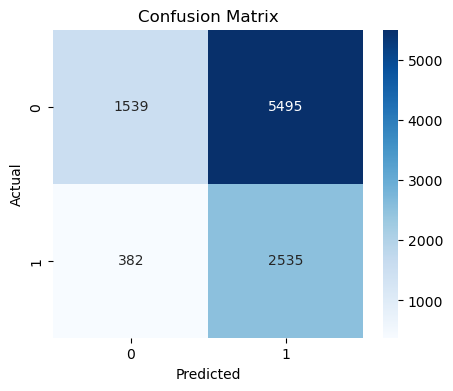

In [172]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#### **🔹 Hyperparameter Tuning using GridSearchCV**

Why Hyperparameter Tuning is needed

- Default model parameters are **not optimal**
- Model performance depends heavily on:
```text
Regularization strength (C)
Penalty type (L1 / L2)

Goal: Find best combination to maximize performance 

**Logistic Regression used because:**

- Interpretable
- Works well with high-dimensional data

**Meaning of parameters**

1. C (Regularization Strength)

    Small C → Strong regularization → simpler model  
    Large C → Weak regularization → complex model

-> Helps control overfitting

2. Penalty
    L1 (Lasso) → feature selection (sparse model)
    L2 (Ridge) → distributes weights smoothly

3. Solver = liblinear
    Supports both L1 and L2


##### GridSearchCV 

**What it does?**
- Tries all combinations of parameters
- Uses 5-fold cross-validation
- Selects best model

**How it works**
- Try parameter combination
- Train on 4 folds
- Validate on 1 fold
- Repeat 5 times
- Average score
- Fit Grid Search
- Best Parameters
- Best Model

In [173]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# model
model = LogisticRegression(max_iter=1000)

# parameter grid
param_grid = {
    'C': np.logspace(-3, 2, 20),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],   # supports both l1 & l2
   
}

# grid search
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
   
)

# fit
grid.fit(X_res, y_res)

# best result
print("Best Params:", grid.best_params_)
print("Best Recall:", grid.best_score_)

Best Params: {'C': np.float64(0.42813323987193913), 'penalty': 'l1', 'solver': 'liblinear'}
Best Recall: 0.6956869881710646


In [174]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_rfe)

from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.4085016581248116
Recall: 0.8683579019540624
Precision: 0.31524579962663346
F1: 0.46256391526661794


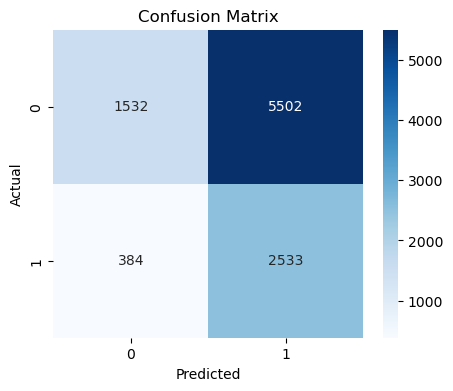

In [175]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#### 🔹 Support Vector Machine (SVM) Model

Why SVM was used

- Churn prediction involves:
```text
Complex + non-linear relationships

**Logistic Regression:**

Linear boundary 

👉 SVM (with RBF kernel):

Captures non-linear patterns 

#### **Parameter Explanation**

1. Kernel = 'rbf'

    Radial Basis Function (non-linear kernel)

- Transforms data into higher dimension
- Helps separate complex patterns

2. C (Regularization)
  
- Low C → smoother boundary (underfit)
- High C → tight boundary (overfit)

3. Gamma = 'scale'

- Controls influence of each point
- Low gamma → broader influence
- High gamma → very tight boundaries

In [176]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',              # non-linear
    C=1,
    gamma='scale',
    
)

svm.fit(X_res, y_res)

SVC(C=1)

In [177]:
y_pred = svm.predict(X_test_rfe)

In [178]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.4354336247613305
Recall: 0.8337332876242715
Precision: 0.32148050231328484
F1: 0.4640335813775997


**Why SVM performed well**
1. Handles non-linearity
2. Works well with high-dimensional data 
3. Combined with SMOTE → better separation 

**Limitation observed**
Training time was high 

Reason:

- SVM is computationally expensive
- Dataset size is large

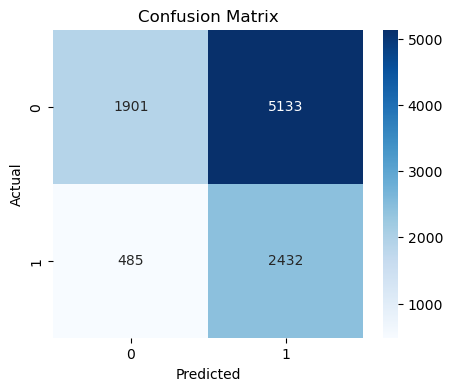

In [179]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#### 🔹 K-Nearest Neighbors (KNN)

What is KNN

- KNN is a **non-parametric, instance-based learning algorithm**
- It does **NOT learn a model explicitly**
- Instead, it:
```text
Stores training data and makes predictions based on nearest neighbors

####   Parameters in KNN

1. n_neighbors (k)


| k Value         | Behavior             |
| --------------- | -------------------- |
| Small k (1–5)   | Noisy, overfitting  |
| Large k (15–25) | Smooth, stable      |

2. weights

- uniform (All neighbors have equal weight)
- distance (Closer neighbors have more importance)

3. metric (distance function)

- Euclidean Distance (Straight Line Distance √[(x1 - x2)² + (y1 - y2)²])
- Manhattan Distance (Grid-based distance |x1 - x2| + |y1 - y2|)

Limitations of KNN

- Slow for large datasets
- Sensitive to noise
- Needs scaling

Why KNN worked well in your project
-  Data was scaled (RobustScaler) ✔
-  SMOTE created balanced clusters ✔
-  Feature selection reduced noise ✔

In [180]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
import pandas as pd

k_range = range(1, 21)
weights_options = ['uniform', 'distance']
metric_options = ['euclidean', 'manhattan']

results = []

for k in k_range:
    for w in weights_options:
        for m in metric_options:
            
            knn = KNeighborsClassifier(
                n_neighbors=k,
                weights=w,
                metric=m
            )
            
            knn.fit(X_res, y_res)
            
            y_pred = knn.predict(X_test_rfe)
            
            acc = accuracy_score(y_test, y_pred)
            rec = recall_score(y_test, y_pred)
            prec = precision_score(y_test,y_pred)
            f1 = f1_score(y_test, y_pred)
            
            results.append({
                'k': k,
                'weights': w,
                'metric': m,
                'Accuracy': acc,
                'Recall': rec,
                'F1': f1
            })

# Convert to DataFrame
results_df = pd.DataFrame(results)
results_df.sort_values(by='Recall', ascending=False)

,k,weights,metric,Accuracy,Recall,F1
72,19,uniform,euclidean,0.437644,0.809393,0.457647
64,17,uniform,euclidean,0.439855,0.800480,0.455877
78,20,distance,euclidean,0.441564,0.794995,0.454929
56,15,uniform,euclidean,0.443272,0.792595,0.454939
74,19,distance,euclidean,0.440458,0.791909,0.453475
...,...,...,...,...,...,...
1,1,uniform,manhattan,0.537333,0.524511,0.399269
3,1,distance,manhattan,0.537333,0.524511,0.399269
7,2,distance,manhattan,0.537333,0.524511,0.399269
4,2,uniform,euclidean,0.550497,0.487830,0.388851


In [181]:
# pick best row
best_row = results_df.sort_values(by='Recall', ascending=False).iloc[0]

best_k = int(best_row['k'])
best_w = best_row['weights']
best_m = best_row['metric']

print("Best Config:", best_k, best_w, best_m)

# train best model
best_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights=best_w,
    metric=best_m
)

best_knn.fit(X_res, y_res)
y_pred = best_knn.predict(X_test_rfe)

Best Config: 19 uniform euclidean


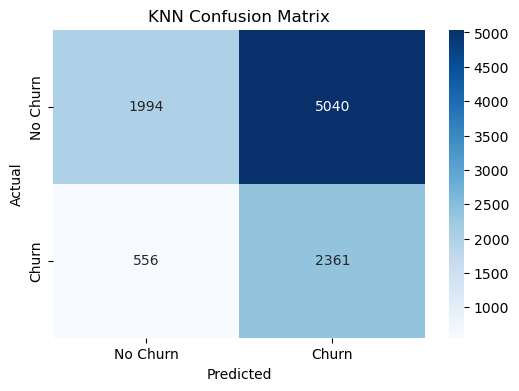

In [182]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

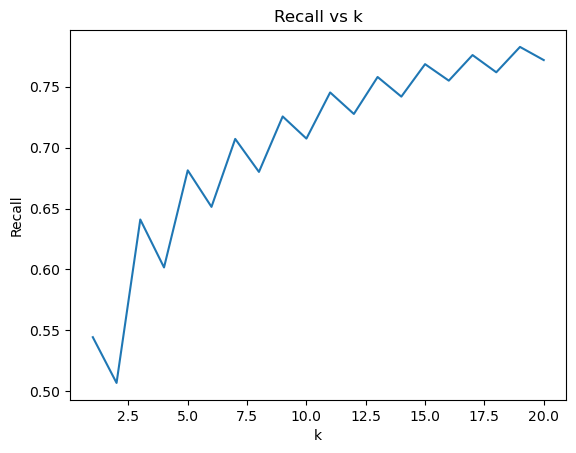

In [183]:
import matplotlib.pyplot as plt

plt.plot(results_df.groupby('k')['Recall'].mean())
plt.xlabel("k")
plt.ylabel("Recall")
plt.title("Recall vs k")
plt.show()

####                                                                            <h1 align='center'>COMPARISON B/W MODELS</h1>

#### 📊Logistic Regression Results

| Technique                     | Accuracy | Recall | Precision | F1 Score |
|------------------------------|----------|--------|-----------|----------|
| RFE + SMOTE-ENN              | 0.410    | 0.892  | 0.319     | 0.470    |
| LASSO + SMOTE-ENN            | 0.349    | 0.948  | 0.299     | 0.455    |
| PCA + SMOTE-ENN              | 0.406    | 0.897  | 0.318     | 0.470    |

#### 📊 SVM Results

| Technique     | Accuracy | Recall | Precision | F1 Score |
|---------------|----------|--------|-----------|----------|
| RFE ⭐         | 0.452    | 0.863  | 0.333     | 0.480    |
| LASSO         | 0.374    | 0.923  | 0.304     | 0.458    |
| PCA           | 0.350    | 0.940  | 0.303     | 0.459    |

📊 KNN Results

| Technique         | Accuracy | Recall | Precision | F1 Score |
|-------------------|----------|--------|-----------|----------|
| RFE (Best)        | 0.422    | 0.839  | 0.460     | 0.461    |
| LASSO (Best)      | 0.317    | 0.959  | 0.290     | 0.446    |
| PCA (Best)        | 0.424    | 0.853  | 0.319     | 0.465    |

<h1 align='center'>🏆 Final Selection</h1>

### Final Model Selected: SVM (RFE)

**Reason:**

**Best overall balance:**
- Highest F1 Score (0.480)
- High Recall (0.863)
- Stable Accuracy → (0.452)
- Balanced performance
- Does not overfit like KNN
- Better trade-off than Logistic

Multiple machine learning models were evaluated including Logistic Regression, Support Vector Machine (SVM), K-Nearest Neighbors (KNN)

Different feature selection techniques (RFE, LASSO, PCA) and class imbalance handling methods (SMOTE, SMOTE-ENN, etc.) were applied to improve performance.

Although some models like Logistic Regression and KNN achieved very high recall, they suffered from low accuracy and instability. 

The SVM model with RFE feature selection achieved the best balance between recall and overall performance (F1-score), making it the most suitable model for this churn prediction task.